# 비건 재료 인식 CNN + AI 레시피 추천 시스템
**기계학습 기말과제** — EfficientNet-B3 Multi-label Classification

## 전체 파이프라인
```
이미지 입력
    ↓
EfficientNet-B3 (Multi-label Classification)
    ↓
여러 재료 동시 예측 [토마토, 양파, 감자, ...]
    ↓
Claude API → 비건 레시피 추천
```

## 왜 EfficientNet-B3인가?
| 모델 | Top-1 Acc | 파라미터 수 | 특징 |
|------|-----------|------------|------|
| ResNet-50 | 76.1% | 25.6M | 깊이만 스케일업 |
| EfficientNet-B0 | 77.1% | 5.3M | 균형잡힌 스케일업 |
| **EfficientNet-B3** | **81.6%** | **12M** | **정확도/효율 최적 균형** |
| EfficientNet-B7 | 84.3% | 66M | 너무 무거움 |

## 왜 Multi-label인가?
- **Multi-class**: Softmax → 재료 1개만 예측
- **Multi-label**: Sigmoid → 재료 여러 개 동시 예측 ← 실제 사진에 필요

In [ ]:
# 패키지 설치 (최초 1회)
# !pip install torch torchvision kaggle fiftyone anthropic scikit-learn matplotlib Pillow --quiet

---
# Step 1. 데이터셋 준비
> **커널 재시작 후 여기서부터 순서대로 실행하세요**

In [1]:
import os, shutil, random, json, time
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ── 경로 설정 (실제 다운로드 경로에 맞게 수정됨) ────────────────
RAW_DIR        = Path("data/raw")
DATA_DIR       = Path("data/processed")
MULTILABEL_DIR = DATA_DIR / "multilabel"
OUTPUT_DIR     = Path("outputs")
IMG_SIZE       = 224

# 실제 Kaggle 다운로드 경로
FRUIT360_ROOT  = RAW_DIR / "fruit360" / "fruits-360_100x100" / "fruits-360"
VEGETABLE_ROOT = RAW_DIR / "vegetable" / "Vegetable Images"

for d in [DATA_DIR, DATA_DIR/"single", MULTILABEL_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 경로 확인
print(f"Fruit-360 경로 존재: {FRUIT360_ROOT.exists()}")
print(f"  Training: {(FRUIT360_ROOT / 'Training').exists()}")
print(f"  Test    : {(FRUIT360_ROOT / 'Test').exists()}")
print(f"Vegetable 경로 존재: {VEGETABLE_ROOT.exists()}")
print(f"  train   : {(VEGETABLE_ROOT / 'train').exists()}")

Fruit-360 경로 존재: True
  Training: True
  Test    : True
Vegetable 경로 존재: True
  train   : True


In [2]:
# ── 클래스 정의 ──────────────────────────────────────────────
FRUIT360_MAP = {
    "Apple Braeburn":"apple", "Apple Crimson Snow":"apple",
    "Apple Golden 1":"apple", "Apple Golden 2":"apple", "Apple Golden 3":"apple",
    "Apple Granny Smith":"apple", "Apple Pink Lady":"apple",
    "Apple Red 1":"apple", "Apple Red 2":"apple", "Apple Red 3":"apple",
    "Apple Red Delicious":"apple", "Apple Red Yellow 1":"apple", "Apple Red Yellow 2":"apple",
    "Banana":"banana", "Banana Lady Finger":"banana", "Banana Red":"banana",
    "Cherry 1":"cherry", "Cherry 2":"cherry", "Cherry Rainier":"cherry",
    "Cherry Wax Black":"cherry", "Cherry Wax Red":"cherry", "Cherry Wax Yellow":"cherry",
    "Grape Blue":"grape", "Grape Pink":"grape", "Grape White":"grape",
    "Grape White 2":"grape", "Grape White 3":"grape", "Grape White 4":"grape",
    "Kiwi":"kiwi",
    "Lemon":"lemon", "Lemon Meyer":"lemon",
    "Mango":"mango", "Mango Red":"mango",
    "Mandarine":"orange", "Orange":"orange",
    "Peach":"peach", "Peach 2":"peach", "Peach Flat":"peach",
    "Pear":"pear", "Pear 2":"pear", "Pear Abate":"pear",
    "Pear Forelle":"pear", "Pear Kaiser":"pear", "Pear Monster":"pear",
    "Pear Red":"pear", "Pear Stone":"pear", "Pear Williams":"pear",
    "Pineapple":"pineapple", "Pineapple Mini":"pineapple",
    "Strawberry":"strawberry", "Strawberry Wedge":"strawberry",
    "Watermelon":"watermelon",
    "Avocado":"avocado", "Avocado ripe":"avocado",
    "Blueberry":"blueberry",
    "Corn":"corn", "Corn Husk":"corn",
    "Tomato 1":"tomato", "Tomato 2":"tomato", "Tomato 3":"tomato",
    "Tomato 4":"tomato", "Tomato Cherry Red":"tomato",
    "Tomato Heart":"tomato", "Tomato Maroon":"tomato",
    "Tomato Yellow":"tomato", "Tomato not Ripened":"tomato",
    "Apricot":"apricot", "Clementine":"clementine", "Cocos":"coconut",
    "Dates":"dates", "Fig":"fig",
    "Grapefruit Pink":"grapefruit", "Grapefruit White":"grapefruit",
    "Guava":"guava", "Lime":"lime", "Lychee":"lychee",
    "Melon Piel de Sapo":"melon", "Mulberry":"mulberry",
    "Nectarine":"nectarine", "Nectarine Flat":"nectarine",
    "Papaya":"papaya", "Passion Fruit":"passion_fruit",
    "Plum":"plum", "Plum 2":"plum", "Plum 3":"plum",
    "Pomegranate":"pomegranate", "Pomelo Sweetie":"pomelo",
    "Raspberry":"raspberry", "Redcurrant":"redcurrant",
    "Tamarillo":"tamarillo",
}

VEGETABLE_MAP = {
    "Bean":"bean", "Bitter Gourd":"bitter_gourd",
    "Bottle Gourd":"bottle_gourd", "Brinjal":"eggplant",
    "Broccoli":"broccoli", "Cabbage":"cabbage",
    "Capsicum":"capsicum", "Carrot":"carrot",
    "Cauliflower":"cauliflower", "Cucumber":"cucumber",
    "Papaya":"papaya", "Potato":"potato",
    "Pumpkin":"pumpkin", "Radish":"radish",
    "Tomato":"tomato",
}

OPEN_IMAGES_MAP = {
    "Mushroom":"mushroom", "Tofu":"tofu",
    "Garlic":"garlic",     "Ginger":"ginger",
    "Onion":"onion",       "Spinach":"spinach",
    "Zucchini":"zucchini", "Leek":"leek",
    "Celery":"celery",     "Asparagus":"asparagus",
}

CLASS_MAP     = {**FRUIT360_MAP, **VEGETABLE_MAP, **OPEN_IMAGES_MAP}
ALL_CLASSES   = sorted(set(CLASS_MAP.values()))
CLASS_TO_IDX  = {c: i for i, c in enumerate(ALL_CLASSES)}
NUM_CLASSES   = len(ALL_CLASSES)

# 클래스 정보 저장
with open(OUTPUT_DIR / "class_info.json", "w", encoding="utf-8") as f:
    json.dump({"classes": ALL_CLASSES, "class_to_idx": CLASS_TO_IDX}, f, ensure_ascii=False, indent=2)

print(f"총 클래스 수: {NUM_CLASSES}")
print(f"클래스 목록: {ALL_CLASSES}")

총 클래스 수: 60
클래스 목록: ['apple', 'apricot', 'asparagus', 'avocado', 'banana', 'bean', 'bitter_gourd', 'blueberry', 'bottle_gourd', 'broccoli', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'celery', 'cherry', 'clementine', 'coconut', 'corn', 'cucumber', 'dates', 'eggplant', 'fig', 'garlic', 'ginger', 'grape', 'grapefruit', 'guava', 'kiwi', 'leek', 'lemon', 'lime', 'lychee', 'mango', 'melon', 'mulberry', 'mushroom', 'nectarine', 'onion', 'orange', 'papaya', 'passion_fruit', 'peach', 'pear', 'pineapple', 'plum', 'pomegranate', 'pomelo', 'potato', 'pumpkin', 'radish', 'raspberry', 'redcurrant', 'spinach', 'strawberry', 'tamarillo', 'tofu', 'tomato', 'watermelon', 'zucchini']


In [3]:
# ── Fruit-360 복사 ───────────────────────────────────────────
def collect_fruit360(split="Training"):
    src_root = FRUIT360_ROOT / split
    count = 0
    missing = []
    for orig_name, unified in FRUIT360_MAP.items():
        src_cls = src_root / orig_name
        if not src_cls.exists():
            missing.append(orig_name)
            continue
        dst_cls = DATA_DIR / "single" / unified
        dst_cls.mkdir(parents=True, exist_ok=True)
        for img in src_cls.glob("*.jpg"):
            dst = dst_cls / f"f360_{split}_{orig_name.replace(' ','_')}_{img.name}"
            if not dst.exists():   # 이미 복사된 파일 스킵
                shutil.copy2(img, dst)
            count += 1
    print(f"Fruit-360 {split}: {count}장 복사 (없는 폴더 {len(missing)}개)")

# ── Vegetable 복사 ───────────────────────────────────────────
def collect_vegetable():
    total = 0
    for split in ["train", "validation", "test"]:
        src_root = VEGETABLE_ROOT / split
        if not src_root.exists():
            continue
        count = 0
        for orig_name, unified in VEGETABLE_MAP.items():
            src_cls = src_root / orig_name
            if not src_cls.exists():
                continue
            dst_cls = DATA_DIR / "single" / unified
            dst_cls.mkdir(parents=True, exist_ok=True)
            for img in src_cls.glob("*.jpg"):
                dst = dst_cls / f"veg_{split}_{img.name}"
                if not dst.exists():
                    shutil.copy2(img, dst)
                count += 1
        print(f"Vegetable {split}: {count}장 복사")
        total += count

print("Fruit-360 복사 중...")
collect_fruit360("Training")
collect_fruit360("Test")

print("\nVegetable 복사 중...")
collect_vegetable()

# 최종 통계
print("\n[single 폴더 통계]")
single_dir = DATA_DIR / "single"
total = 0
for cls_dir in sorted(single_dir.iterdir()):
    if cls_dir.is_dir():
        n = len(list(cls_dir.glob("*.*")))
        total += n
print(f"클래스 수: {len([d for d in single_dir.iterdir() if d.is_dir()])}")
print(f"총 이미지: {total}장")

Fruit-360 복사 중...
Fruit-360 Training: 12094장 복사 (없는 폴더 69개)
Fruit-360 Test: 4039장 복사 (없는 폴더 69개)

Vegetable 복사 중...
Vegetable train: 13000장 복사
Vegetable validation: 2600장 복사
Vegetable test: 2600장 복사

[single 폴더 통계]
클래스 수: 29
총 이미지: 37333장


In [4]:
# ── Mosaic Augmentation으로 Multi-label 데이터 생성 ───────────
def make_mosaic(img_paths, grid=(1,2)):
    rows, cols = grid
    cell_h, cell_w = IMG_SIZE // rows, IMG_SIZE // cols
    canvas = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
    for idx, p in enumerate(img_paths[:rows*cols]):
        r, c = divmod(idx, cols)
        img = Image.open(p).convert("RGB").resize((cell_w, cell_h))
        canvas.paste(img, (c * cell_w, r * cell_h))
    return canvas

def generate_multilabel_dataset(n_samples=3000, seed=42):
    random.seed(seed)
    MULTILABEL_DIR.mkdir(parents=True, exist_ok=True)

    # 클래스별 이미지 수집
    class_images = {}
    for cls in ALL_CLASSES:
        cls_dir = DATA_DIR / "single" / cls
        if cls_dir.exists():
            imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
            if imgs:
                class_images[cls] = imgs

    available = list(class_images.keys())
    print(f"사용 가능한 클래스: {len(available)}종")
    print(f"생성할 Mosaic 수: {n_samples}장")

    annotations = []
    for i in range(n_samples):
        n_cls  = random.choice([2, 2, 3, 4])
        chosen = random.sample(available, min(n_cls, len(available)))
        paths  = [random.choice(class_images[c]) for c in chosen]
        grid   = (1, 2) if len(chosen) == 2 else (2, 2)

        mosaic = make_mosaic(paths, grid)
        fname  = f"mosaic_{i:05d}.jpg"
        mosaic.save(MULTILABEL_DIR / fname, quality=90)

        label_vec = [0] * NUM_CLASSES
        for c in chosen:
            label_vec[CLASS_TO_IDX[c]] = 1
        annotations.append({"file": fname, "labels": label_vec, "classes": chosen})

        if (i+1) % 500 == 0:
            print(f"  {i+1}/{n_samples} 완료", flush=True)

    with open(DATA_DIR / "multilabel_annotations.json", "w") as f:
        json.dump({"classes": ALL_CLASSES, "samples": annotations}, f)

    print(f"\nMosaic 생성 완료: {n_samples}장")
    return annotations

annotations = generate_multilabel_dataset(n_samples=3000)

사용 가능한 클래스: 29종
생성할 Mosaic 수: 3000장
  500/3000 완료
  1000/3000 완료
  1500/3000 완료
  2000/3000 완료
  2500/3000 완료
  3000/3000 완료

Mosaic 생성 완료: 3000장


In [5]:
# ── Train / Val / Test 분리 ───────────────────────────────────
random.seed(42)
random.shuffle(annotations)
n = len(annotations)
splits = {
    "train": annotations[:int(n*0.7)],
    "val"  : annotations[int(n*0.7):int(n*0.85)],
    "test" : annotations[int(n*0.85):],
}
with open(DATA_DIR / "splits.json", "w") as f:
    json.dump(splits, f)

print(f"train: {len(splits['train'])}장")
print(f"val  : {len(splits['val'])}장")
print(f"test : {len(splits['test'])}장")
print("Step 1 완료!")

train: 2100장
val  : 450장
test : 450장
Step 1 완료!


---
# Step 2. CNN 학습 — EfficientNet-B3 Multi-label
> **커널 재시작 시 Step 1 설정 셀들을 먼저 실행한 후 여기서부터 실행하세요**

In [1]:
# ── Step 2 초기화 (커널 재시작 후 여기서 시작) ────────────────
import json, time
from pathlib import Path
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR

DATA_DIR       = Path("data/processed")
MULTILABEL_DIR = DATA_DIR / "multilabel"
OUTPUT_DIR     = Path("outputs")

# 클래스 정보 로드
with open(OUTPUT_DIR / "class_info.json", encoding="utf-8") as f:
    class_info = json.load(f)
ALL_CLASSES  = class_info["classes"]
CLASS_TO_IDX = class_info["class_to_idx"]
NUM_CLASSES  = len(ALL_CLASSES)

# splits 로드
with open(DATA_DIR / "splits.json") as f:
    splits = json.load(f)

CONFIG = {
    "img_size"    : 224,
    "batch_size"  : 32,
    "num_epochs"  : 30,
    "lr"          : 1e-3,
    "weight_decay": 1e-4,
    "freeze_until": 5,
    "threshold"   : 0.5,
    "seed"        : 42,
}

torch.manual_seed(CONFIG["seed"])

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# Windows CPU면 num_workers=0, GPU면 4
NW = 0 

print(f"사용 장치: {DEVICE}")
print(f"num_workers: {NW}")
print(f"클래스 수: {NUM_CLASSES}")
print(f"train: {len(splits['train'])}장 / val: {len(splits['val'])}장")

사용 장치: cuda
num_workers: 0
클래스 수: 60
train: 2100장 / val: 450장


In [2]:
# ── Dataset & DataLoader ─────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

class VeganDataset(Dataset):
    def __init__(self, annotations, img_dir, transform=None):
        self.ann       = annotations
        self.img_dir   = Path(img_dir)
        self.transform = transform
    def __len__(self):
        return len(self.ann)
    def __getitem__(self, idx):
        a   = self.ann[idx]
        img = Image.open(self.img_dir / a["file"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.FloatTensor(a["labels"])

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG["img_size"], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = VeganDataset(splits["train"], MULTILABEL_DIR, train_tf)
val_ds   = VeganDataset(splits["val"],   MULTILABEL_DIR, val_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=NW, pin_memory=(DEVICE.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=NW, pin_memory=(DEVICE.type=="cuda"))

# 속도 테스트
t0 = time.time()
imgs, labels = next(iter(train_loader))
print(f"데이터 로딩 속도: {time.time()-t0:.2f}s (배치 {imgs.shape})")

데이터 로딩 속도: 0.56s (배치 torch.Size([32, 3, 224, 224]))


In [3]:
# ── EfficientNet-B3 모델 ─────────────────────────────────────
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(512, NUM_CLASSES),
)
model = model.to(DEVICE)

# pos_weight (클래스 불균형 보정)
all_labels = np.array([s["labels"] for s in splits["train"]])
pos_count  = all_labels.sum(axis=0) + 1e-6
neg_count  = len(all_labels) - pos_count
pos_weight = torch.FloatTensor(neg_count / pos_count).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.classifier.parameters(),
                        lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터: {total:,} / 학습 파라미터: {trainable:,}")
print("모델 준비 완료")

전체 파라미터: 11,513,956 / 학습 파라미터: 817,724
모델 준비 완료


In [4]:
# ── 학습 루프 ────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, all_preds, all_targets = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) >= CONFIG["threshold"]).float()
        all_preds.append(preds.cpu())
        all_targets.append(labels.cpu())
    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    exact = (all_preds == all_targets).all(dim=1).float().mean().item()
    return total_loss / len(loader.dataset), exact

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) >= CONFIG["threshold"]).float()
        all_preds.append(preds.cpu())
        all_targets.append(labels.cpu())
    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    exact   = (all_preds == all_targets).all(dim=1).float().mean().item()
    hamming = (all_preds == all_targets).float().mean().item()
    return total_loss / len(loader.dataset), exact, hamming

best_val_loss = float("inf")
history = {"train_loss":[], "train_exact":[], "val_loss":[], "val_exact":[], "val_hamming":[]}

print("학습 시작!")
print("-" * 85)

for epoch in range(1, CONFIG["num_epochs"] + 1):
    t0 = time.time()

    if epoch == CONFIG["freeze_until"] + 1:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW([
            {"params": model.features[:4].parameters(), "lr": CONFIG["lr"] * 0.01},
            {"params": model.features[4:].parameters(), "lr": CONFIG["lr"] * 0.1},
            {"params": model.classifier.parameters(),   "lr": CONFIG["lr"]},
        ], weight_decay=CONFIG["weight_decay"])
        scheduler = CosineAnnealingLR(
            optimizer, T_max=CONFIG["num_epochs"] - CONFIG["freeze_until"])
        print("  [unfreeze] backbone 전체 학습 시작", flush=True)

    train_loss, train_exact             = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_exact,  val_hamming = validate(model, val_loader, criterion)
    scheduler.step()

    elapsed = time.time() - t0
    frozen  = "frozen" if epoch <= CONFIG["freeze_until"] else "fine-tune"
    print(
        f"[{epoch:02d}/{CONFIG['num_epochs']:02d}] {frozen:>9} | "
        f"loss {train_loss:.4f} exact {train_exact:.4f} | "
        f"val_loss {val_loss:.4f} exact {val_exact:.4f} hamming {val_hamming:.4f} | "
        f"{elapsed:.1f}s",
        flush=True
    )

    for k, v in zip(history, [train_loss, train_exact, val_loss, val_exact, val_hamming]):
        history[k].append(round(v, 4))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "val_loss": val_loss, "val_exact": val_exact,
            "num_classes": NUM_CLASSES, "config": CONFIG,
        }, OUTPUT_DIR / "best_model.pth")
        print(f"  ✓ best model 저장 (val_loss={val_loss:.4f})", flush=True)

with open(OUTPUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"\n학습 완료! 최저 val_loss: {best_val_loss:.4f}")

학습 시작!
-------------------------------------------------------------------------------------
[01/30]    frozen | loss 0.5904 exact 0.0000 | val_loss 0.4632 exact 0.0000 hamming 0.8606 | 36.4s
  ✓ best model 저장 (val_loss=0.4632)
[02/30]    frozen | loss 0.4500 exact 0.0033 | val_loss 0.3964 exact 0.0044 hamming 0.8897 | 23.6s
  ✓ best model 저장 (val_loss=0.3964)
[03/30]    frozen | loss 0.4112 exact 0.0024 | val_loss 0.3727 exact 0.0044 hamming 0.8878 | 16.6s
  ✓ best model 저장 (val_loss=0.3727)
[04/30]    frozen | loss 0.3924 exact 0.0014 | val_loss 0.3597 exact 0.0067 hamming 0.9032 | 17.0s
  ✓ best model 저장 (val_loss=0.3597)
[05/30]    frozen | loss 0.3758 exact 0.0086 | val_loss 0.3461 exact 0.0067 hamming 0.9129 | 18.4s
  ✓ best model 저장 (val_loss=0.3461)
  [unfreeze] backbone 전체 학습 시작
[06/30] fine-tune | loss 0.3464 exact 0.0171 | val_loss 0.2941 exact 0.0467 hamming 0.9224 | 29.0s
  ✓ best model 저장 (val_loss=0.2941)
[07/30] fine-tune | loss 0.2909 exact 0.0419 | val_loss 0.2607 exa

---
# Step 3. 모델 평가 — Multi-label 지표

| 지표 | 설명 |
|------|------|
| Exact Match | 모든 레이블 완전 일치 비율 |
| Hamming Accuracy | 레이블 단위 정확도 |
| F1 micro | 전체 TP/FP/FN 기준 F1 |
| F1 macro | 클래스별 F1 평균 |
| mAP | 클래스별 Average Precision 평균 |

## 점수별 개선 방향
| 지표 | 낮을 때 개선 방법 |
|------|------------------|
| Exact Match < 0.5 | threshold 조정, 데이터 늘리기 |
| F1 micro < 0.7 | 에폭 늘리기, lr 조정 |
| F1 macro << F1 micro | AP 하위 클래스 데이터 보강 |
| train >> val (과적합) | Dropout 강화, Augmentation 추가 |

In [5]:
# ── Step 3 초기화 (커널 재시작 후 Step 2 초기화 셀 먼저 실행) ──
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, hamming_loss, average_precision_score

# 모델 로드
ckpt = torch.load(OUTPUT_DIR / "best_model.pth", map_location=DEVICE)
eval_model = models.efficientnet_b3(weights=None)
in_features = eval_model.classifier[1].in_features
eval_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3), nn.Linear(in_features, 512),
    nn.ReLU(), nn.Dropout(p=0.2), nn.Linear(512, NUM_CLASSES),
)
eval_model.load_state_dict(ckpt["model_state"])
eval_model.to(DEVICE).eval()
print(f"모델 로드 완료 (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

# Test 추론
test_ds     = VeganDataset(splits["test"], MULTILABEL_DIR, val_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

all_probs, all_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = torch.sigmoid(eval_model(imgs.to(DEVICE))).cpu()
        all_probs.append(probs)
        all_targets.append(labels)

all_probs   = torch.cat(all_probs).numpy()
all_targets = torch.cat(all_targets).numpy()
all_preds   = (all_probs >= CONFIG["threshold"]).astype(int)

# 평가 지표
exact   = (all_preds == all_targets).all(axis=1).mean()
hamming = 1 - hamming_loss(all_targets, all_preds)
f1_mi   = f1_score(all_targets, all_preds, average="micro",   zero_division=0)
f1_ma   = f1_score(all_targets, all_preds, average="macro",   zero_division=0)
f1_sa   = f1_score(all_targets, all_preds, average="samples", zero_division=0)
mAP     = average_precision_score(all_targets, all_probs, average="macro")

print("=" * 45)
print("Multi-label 평가 결과")
print("=" * 45)
print(f"Exact Match Ratio : {exact:.4f} ({exact*100:.2f}%)")
print(f"Hamming Accuracy  : {hamming:.4f} ({hamming*100:.2f}%)")
print(f"F1 micro          : {f1_mi:.4f}")
print(f"F1 macro          : {f1_ma:.4f}")
print(f"F1 samples        : {f1_sa:.4f}")
print(f"mAP               : {mAP:.4f}")

with open(OUTPUT_DIR / "eval_results.json", "w") as f:
    json.dump({"exact_match": round(float(exact),4), "hamming": round(float(hamming),4),
               "f1_micro": round(float(f1_mi),4), "f1_macro": round(float(f1_ma),4),
               "f1_samples": round(float(f1_sa),4), "mAP": round(float(mAP),4)}, f, indent=2)

모델 로드 완료 (epoch 15, val_loss=0.2073)
Multi-label 평가 결과
Exact Match Ratio : 0.2467 (24.67%)
Hamming Accuracy  : 0.9495 (94.95%)
F1 micro          : 0.6107
F1 macro          : 0.3501
F1 samples        : 0.6599
mAP               : 0.3544


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: N

In [6]:
# ── 클래스별 AP (상위/하위 10개) ──────────────────────────────
per_ap = average_precision_score(all_targets, all_probs, average=None)
ap_df  = sorted(zip(ALL_CLASSES, per_ap), key=lambda x: -x[1])

print("[AP 상위 10 클래스]")
for name, ap in ap_df[:10]:
    print(f"  {name:<20} {ap:.4f}  {'█'*int(ap*20)}")

print("\n[AP 하위 10 클래스 — 데이터 보강 필요]")
for name, ap in ap_df[-10:]:
    print(f"  {name:<20} {ap:.4f}  {'█'*int(ap*20)}")

[AP 상위 10 클래스]
  peach                1.0000  ████████████████████
  plum                 1.0000  ████████████████████
  pear                 1.0000  ███████████████████
  carrot               0.9996  ███████████████████
  cabbage              0.9985  ███████████████████
  radish               0.9982  ███████████████████
  grape                0.9981  ███████████████████
  potato               0.9975  ███████████████████
  pumpkin              0.9954  ███████████████████
  broccoli             0.9941  ███████████████████

[AP 하위 10 클래스 — 데이터 보강 필요]
  orange               -0.0000  
  passion_fruit        -0.0000  
  pineapple            -0.0000  
  pomegranate          -0.0000  
  pomelo               -0.0000  
  raspberry            -0.0000  
  redcurrant           -0.0000  
  strawberry           -0.0000  
  tamarillo            -0.0000  
  watermelon           -0.0000  


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:993: UserWarning: N

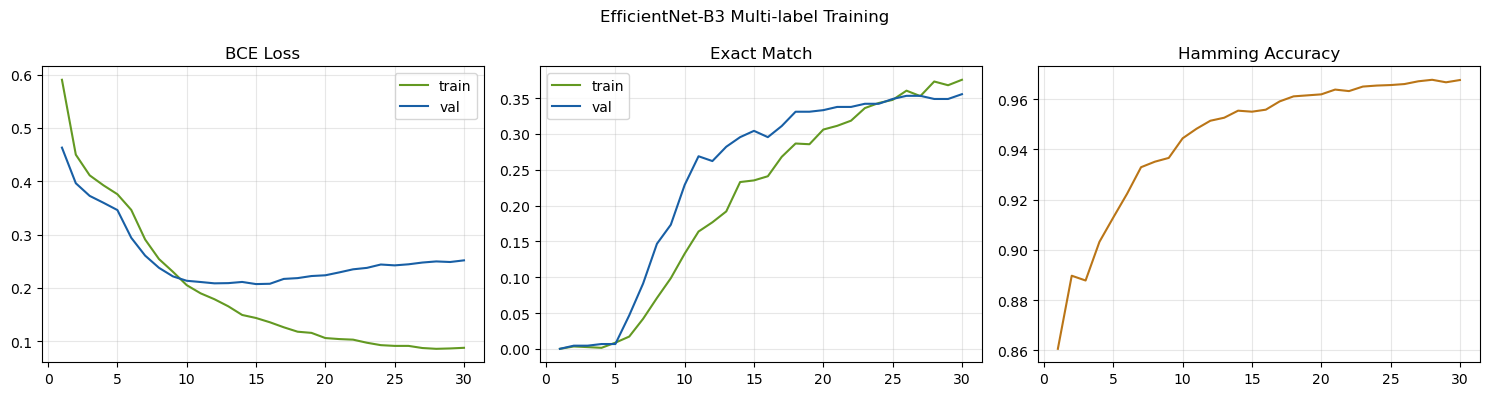

In [7]:
# ── 학습 곡선 ────────────────────────────────────────────────
with open(OUTPUT_DIR / "history.json") as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="train", color="#639922")
axes[0].plot(ep, history["val_loss"],   label="val",   color="#185FA5")
axes[0].set_title("BCE Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_exact"], label="train", color="#639922")
axes[1].plot(ep, history["val_exact"],   label="val",   color="#185FA5")
axes[1].set_title("Exact Match"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["val_hamming"], color="#BA7517")
axes[2].set_title("Hamming Accuracy"); axes[2].grid(alpha=0.3)

plt.suptitle("EfficientNet-B3 Multi-label Training")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

---
# Step 4. 추론 + Claude API 레시피 추천

- `IMAGE_PATH`: 테스트할 이미지 경로
- `ANTHROPIC_KEY`: https://console.anthropic.com 에서 발급

In [15]:
# pillow-avif-plugin 설치
import subprocess
subprocess.run(["pip", "install", "pillow-avif-plugin"], check=True)

import pillow_avif
from PIL import Image
from pathlib import Path

# avif → jpg 변환
src = Path(r"C:\Project\ML_project\test_image.avif")
dst = Path(r"C:\Project\ML_project\test_image.jpg")

img = Image.open(src).convert("RGB")
img.save(dst, "JPEG", quality=95)
print(f"변환 완료: {dst}")

# 변환된 파일로 테스트
IMAGE_PATH = str(dst)

변환 완료: C:\Project\ML_project\test_image.jpg


DEVICE: cuda
모델 로드 완료 (epoch 15)

[재료 예측 결과] threshold=0.5
----------------------------------------
  ✓ zucchini             0.9963  ███████████████████
  ✓ cauliflower          0.9649  ███████████████████
  ✓ tomato               0.9646  ███████████████████
  ✓ capsicum             0.9395  ██████████████████
  ✓ mushroom             0.8751  █████████████████
  ✓ cabbage              0.6580  █████████████
    carrot               0.1947  ███
    radish               0.1870  ███
    onion                0.0851  █
    garlic               0.0836  █
    spinach              0.0818  █
    asparagus            0.0810  █
    cucumber             0.0413  
    bean                 0.0410  
    pumpkin              0.0267  

감지된 재료: ['zucchini', 'cauliflower', 'tomato', 'capsicum', 'mushroom', 'cabbage']


C:\Users\admin\AppData\Local\Temp\ipykernel_27796\1674812909.py:82: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from current font.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_27796\1674812909.py:82: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_27796\1674812909.py:82: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from current font.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_27796\1674812909.py:82: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from current font.
  plt.tight_layout()
C:\Users\admin\AppData\Local\Temp\ipykernel_27796\1674812909.py:82: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from current font.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from current font.
  fig.canvas

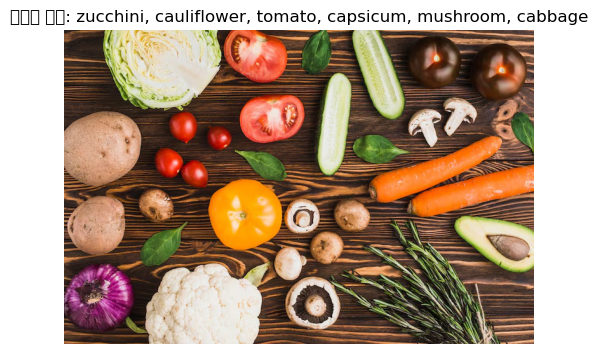


threshold별 감지 재료 수
----------------------------------------
  0.3: 6개 → ['cabbage', 'capsicum', 'cauliflower', 'mushroom', 'tomato', 'zucchini']
  0.4: 6개 → ['cabbage', 'capsicum', 'cauliflower', 'mushroom', 'tomato', 'zucchini']
  0.5: 6개 → ['cabbage', 'capsicum', 'cauliflower', 'mushroom', 'tomato', 'zucchini']
  0.6: 6개 → ['cabbage', 'capsicum', 'cauliflower', 'mushroom', 'tomato', 'zucchini']
  0.7: 5개 → ['capsicum', 'cauliflower', 'mushroom', 'tomato', 'zucchini']


In [16]:
# ── Step 4: 이미지 재료 예측만 ───────────────────────────────
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from pathlib import Path
from torchvision import transforms, models
import matplotlib.pyplot as plt
import json

# 설정
IMAGE_PATH = "C:/Project/ML_project/test_image.jpg"   # ← 테스트 이미지 경로로 변경
THRESHOLD  = 0.5                # ← 낮추면 더 많은 재료 감지

OUTPUT_DIR     = Path("C:/Project/ML_project/outputs")
MULTILABEL_DIR = Path("C:/Project/ML_project/data/processed/multilabel")

# 클래스 정보 로드
with open(OUTPUT_DIR / "class_info.json", encoding="utf-8") as f:
    class_info = json.load(f)
ALL_CLASSES  = class_info["classes"]
NUM_CLASSES  = len(ALL_CLASSES)

# DEVICE
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"DEVICE: {DEVICE}")

# 모델 로드
ckpt = torch.load(OUTPUT_DIR / "best_model.pth", map_location=DEVICE)
infer_model = models.efficientnet_b3(weights=None)
in_features = infer_model.classifier[1].in_features
infer_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3), nn.Linear(in_features, 512),
    nn.ReLU(), nn.Dropout(p=0.2), nn.Linear(512, NUM_CLASSES),
)
infer_model.load_state_dict(ckpt["model_state"])
infer_model.to(DEVICE).eval()
print(f"모델 로드 완료 (epoch {ckpt['epoch']})")

# 전처리
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
infer_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# 이미지 로드 & 예측
img    = Image.open(IMAGE_PATH).convert("RGB")
tensor = infer_tf(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    probs = torch.sigmoid(infer_model(tensor))[0].cpu().numpy()

# 결과 출력
detected = []
print(f"\n[재료 예측 결과] threshold={THRESHOLD}")
print("-" * 40)
for idx in np.argsort(probs)[::-1][:15]:
    name = ALL_CLASSES[idx]
    prob = probs[idx]
    mark = "✓" if prob >= THRESHOLD else " "
    bar  = "█" * int(prob * 20)
    print(f"  {mark} {name:<20} {prob:.4f}  {bar}")
    if prob >= THRESHOLD:
        detected.append(name)

print(f"\n감지된 재료: {detected}")

# 이미지 시각화
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"감지된 재료: {', '.join(detected)}")
plt.tight_layout()
plt.show()

# threshold 조정 실험
print("\nthreshold별 감지 재료 수")
print("-" * 40)
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    det = [ALL_CLASSES[i] for i, p in enumerate(probs) if p >= th]
    print(f"  {th}: {len(det)}개 → {det}")

In [ ]:
# ── Step 4 초기화 (커널 재시작 후 Step 2 초기화 셀 먼저 실행) ──
import re
import anthropic

IMAGE_PATH    = "test_image.jpg"   # ← 테스트 이미지 경로
THRESHOLD     = 0.5                # ← 낮추면 더 많은 재료 감지
ANTHROPIC_KEY = ""                 # ← Claude API 키

# 모델 로드
ckpt = torch.load(OUTPUT_DIR / "best_model.pth", map_location=DEVICE)
infer_model = models.efficientnet_b3(weights=None)
in_features = infer_model.classifier[1].in_features
infer_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3), nn.Linear(in_features, 512),
    nn.ReLU(), nn.Dropout(p=0.2), nn.Linear(512, NUM_CLASSES),
)
infer_model.load_state_dict(ckpt["model_state"])
infer_model.to(DEVICE).eval()
print("모델 로드 완료")

infer_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

In [ ]:
# ── 재료 예측 ─────────────────────────────────────────────────
img    = Image.open(IMAGE_PATH).convert("RGB")
tensor = infer_tf(img).unsqueeze(0).to(DEVICE)

plt.figure(figsize=(5,5))
plt.imshow(img); plt.axis("off"); plt.title("입력 이미지"); plt.show()

with torch.no_grad():
    probs = torch.sigmoid(infer_model(tensor))[0].cpu().numpy()

detected = []
print(f"\n[Multi-label 분류 결과] (threshold={THRESHOLD})")
print(f"{'재료':<20} {'확률':>6}")
print("-" * 30)
for idx in np.argsort(probs)[::-1][:15]:
    name = ALL_CLASSES[idx]
    prob = probs[idx]
    mark = "✓" if prob >= THRESHOLD else " "
    print(f"  {mark} {name:<18} {prob:.4f}  {'█'*int(prob*20)}")
    if prob >= THRESHOLD:
        detected.append(name)

print(f"\n감지된 재료: {detected}")

In [ ]:
# ── Claude API 레시피 추천 ────────────────────────────────────
def recommend_recipes(ingredients, api_key, n=3):
    if not api_key:
        print("[오류] ANTHROPIC_KEY를 입력해주세요")
        return None
    if not ingredients:
        print("[오류] 감지된 재료가 없어요. THRESHOLD를 낮춰보세요")
        return None

    client = anthropic.Anthropic(api_key=api_key)
    prompt = f"""당신은 전문 비건 요리사입니다.

CNN 모델이 이미지에서 다음 재료들을 감지했습니다:
{', '.join(ingredients)}

이 재료들을 활용한 비건 레시피 {n}가지를 추천해주세요.
다른 텍스트 없이 아래 JSON 형식으로만 응답하세요:
{{
  "recipes": [
    {{
      "name": "레시피 이름",
      "used_ingredients": ["사용 재료"],
      "extra_ingredients": ["추가 재료 (선택)"],
      "steps": ["1. 조리 순서"],
      "time_minutes": 30,
      "difficulty": "쉬움"
    }}
  ]
}}"""

    print("[Claude API] 레시피 추천 요청 중...")
    msg = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=1500,
        messages=[{"role": "user", "content": prompt}]
    )
    raw = msg.content[0].text
    match = re.search(r'\{.*\}', raw, re.DOTALL)
    return json.loads(match.group() if match else raw)

result = recommend_recipes(detected, ANTHROPIC_KEY)

if result and "recipes" in result:
    medals = ["🥇","🥈","🥉"]
    print("\n" + "="*50)
    print("Claude 비건 레시피 추천")
    print("="*50)
    for i, r in enumerate(result["recipes"]):
        print(f"\n{medals[i] if i<3 else i+1} {r['name']}")
        print(f"   ⏱ {r.get('time_minutes','?')}분  난이도: {r.get('difficulty','?')}")
        print(f"   사용 재료: {', '.join(r['used_ingredients'])}")
        if r.get('extra_ingredients'):
            print(f"   추가 재료: {', '.join(r['extra_ingredients'])}")
        print("   조리법:")
        for step in r.get('steps',[]):
            print(f"     {step}")

In [ ]:
# ── threshold 조정 실험 ───────────────────────────────────────
print("threshold별 감지 재료 수")
print("-" * 40)
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    det = [ALL_CLASSES[i] for i,p in enumerate(probs) if p >= th]
    print(f"  {th}: {len(det)}개 → {det}")